# Regression Model Comparison

## Overview
This notebook focuses on the comparative evaluation of multiple machine learning regression algorithms for predicting compound bioactivity using molecular descriptor data.

The workflow includes:
- Dataset preparation
- Model training across multiple regression algorithms
- Performance evaluation and benchmarking
- Comparative analysis of predictive accuracy

## Objectives
The objective is to identify and compare regression models capable of accurately predicting pIC50 values for acetylcholinesterase inhibitors.

## Models Evaluated
- Linear Regression
- Random Forest Regressor
- Support Vector Regressor (SVR)
- Decision Tree Regressor
- Additional regression algorithms as applicable

## Tools and Libraries
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Acknowledgment
Initial workflow inspired by educational content from Data Professor.

## Import Required Libraries

In [1]:
! pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## Load Modeling Dataset

In [3]:
! wget https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv

--2026-05-03 20:28:05--  https://github.com/dataprofessor/data/raw/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv [following]
--2026-05-03 20:28:06--  https://raw.githubusercontent.com/dataprofessor/data/master/acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8363909 (8.0M) [text/plain]
Saving to: ‘acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_

In [4]:
df = pd.read_csv('acetylcholinesterase_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [5]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## **3. Data pre-processing**

In [6]:
# Examine X dimension
X.shape

(4695, 881)

In [7]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(4695, 137)

In [12]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **4. Compare ML algorithms**

In [15]:
print(type(predictions_train))
print(predictions_train)
print(models_train)

<class 'pandas.core.frame.DataFrame'>
Empty DataFrame
Columns: []
Index: []
                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
ExtraTreeRegressor                       0.859408   0.864538  0.571388   
DecisionTreeRegressor                    0.859408   0.864538  0.571388   
ExtraTreesRegressor                      0.859408   0.864538  0.571388   
GaussianProcessRegressor                 0.859408   0.864538  0.571388   
RandomForestRegressor                    0.822878   0.829340  0.641338   
XGBRegressor                             0.819598   0.826180  0.647249   
BaggingRegressor                         0.804288   0.811428  0.674155   
MLPRegressor                             0.757521   0.766367  0.750392   
HistGradientBoostingRegressor            0.674207   0.686094  0.869805   
LGBMRegressor                            0.654373   0.666983  0.895890   
KNeighborsRegressor                 

In [16]:
clf = LazyRegressor(verbose=1, ignore_warnings=False, custom_metric=None)
models_train, predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test, predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

  0%|          | 0/42 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.7337518558579177, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.8408352557162289, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.7461886438486545, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

  0%|          | 0/42 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.7337518558579177, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.8408352557162289, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.7461886438486545, tolerance: 0.7227671041903794
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converge

In [19]:
print(models_train)

                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
ExtraTreeRegressor                       0.859408   0.864538  0.571388   
DecisionTreeRegressor                    0.859408   0.864538  0.571388   
ExtraTreesRegressor                      0.859408   0.864538  0.571388   
GaussianProcessRegressor                 0.859408   0.864538  0.571388   
RandomForestRegressor                    0.822878   0.829340  0.641338   
XGBRegressor                             0.819598   0.826180  0.647249   
BaggingRegressor                         0.804288   0.811428  0.674155   
MLPRegressor                             0.757521   0.766367  0.750392   
HistGradientBoostingRegressor            0.674207   0.686094  0.869805   
LGBMRegressor                            0.654373   0.666983  0.895890   
KNeighborsRegressor                      0.633506   0.646877  0.922539   
SVR                                   

In [21]:
# Performance table of the test set (20% subset)
print(models_test)

                               Adjusted R-Squared  R-Squared      RMSE  \
Model                                                                    
HistGradientBoostingRegressor            0.455519   0.535044  1.059035   
RandomForestRegressor                    0.438623   0.520616  1.075341   
LGBMRegressor                            0.437692   0.519820  1.076233   
XGBRegressor                             0.436528   0.518826  1.077346   
BaggingRegressor                         0.405035   0.491933  1.107044   
NuSVR                                    0.389303   0.478499  1.121584   
SVR                                      0.389268   0.478469  1.121616   
KNeighborsRegressor                      0.371334   0.463154  1.137965   
MLPRegressor                             0.358628   0.452304  1.149408   
GradientBoostingRegressor                0.325779   0.424252  1.178475   
ExtraTreesRegressor                      0.221959   0.335596  1.265961   
DecisionTreeRegressor                 

## **5. Data visualization of model performance**

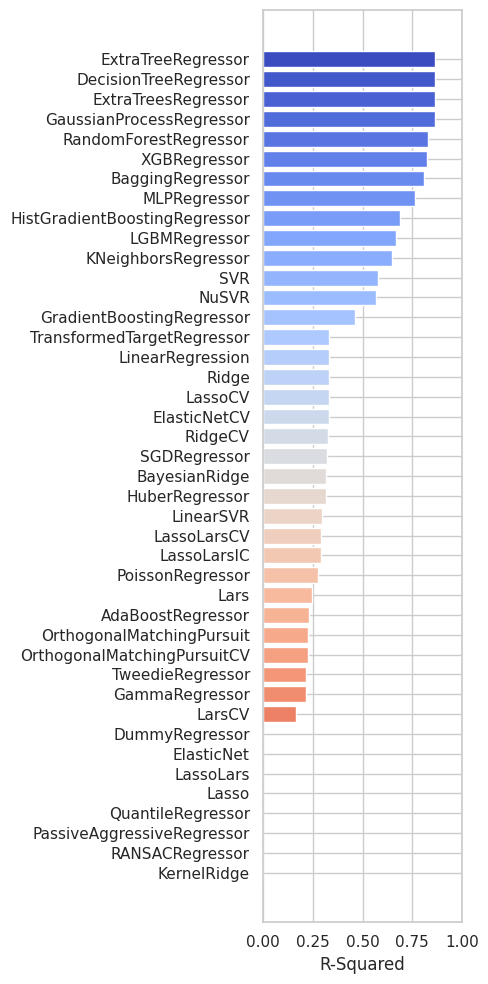

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(5, 10))

values = models_train["R-Squared"].values
colors = cm.coolwarm(np.linspace(0, 1, len(values)))

ax.barh(models_train.index, values, color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("R-Squared")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

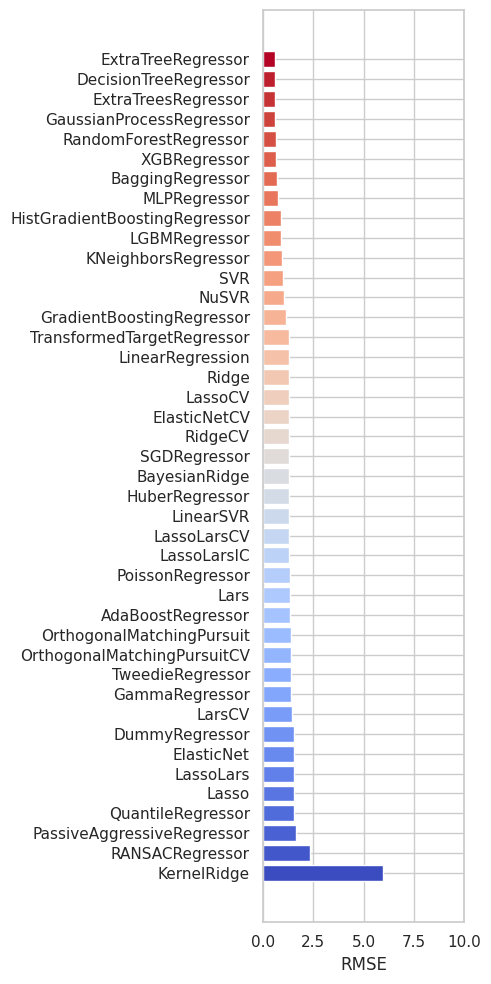

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(5, 10))

values = models_train["RMSE"].values
colors = cm.coolwarm(np.linspace(1, 0, len(values)))  # reversed so low RMSE = blue

ax.barh(models_train.index, values, color=colors)
ax.set_xlim(0, 10)
ax.set_xlabel("RMSE")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

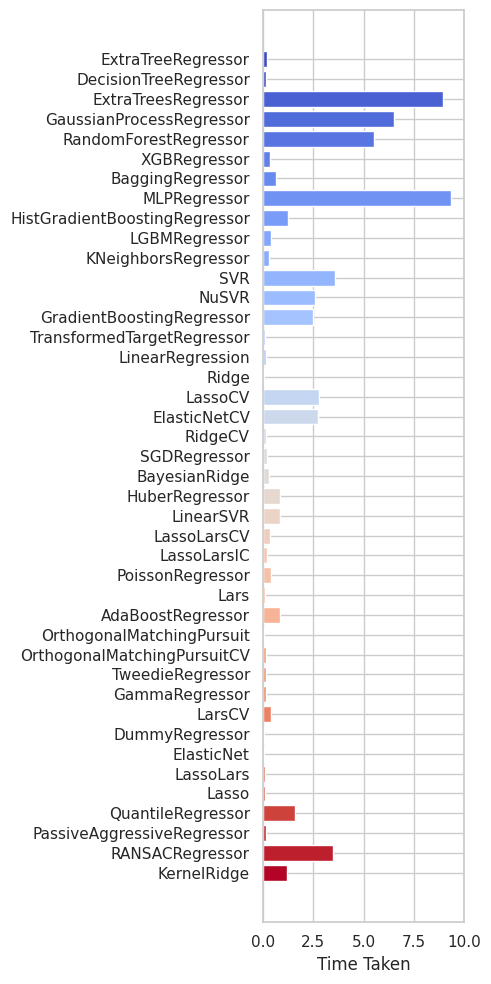

In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(5, 10))

values = models_train["Time Taken"].values
colors = cm.coolwarm(np.linspace(0, 1, len(values)))

ax.barh(models_train.index, values, color=colors)
ax.set_xlim(0, 10)
ax.set_xlabel("Time Taken")
ax.invert_yaxis()
plt.tight_layout()
plt.show()